In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict

In [32]:
baseline_meanlists = {}
baseline_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data_compute_scaling_study"):
    dlist = []
    
    for csvfile in os.listdir(f"data_compute_scaling_study/{checkpoint}/baseline/"):
        data = pd.read_csv(f"data_compute_scaling_study/{checkpoint}/baseline/{csvfile}")
    
        dlist.append(data["LNK"].to_list())
        baseline_compute_max_map[int(checkpoint)].append(max(data["LNK"].to_list()))

    meanlist = []
    for idx in range(max([len(x) for x in dlist])):
        i = 0
        summe = 0
        for dl in dlist:
            try:
                summe += dl[idx]
                i += 1
            except:
                pass
        meanlist.append(summe / i)
    baseline_meanlists[checkpoint] = meanlist

In [33]:
meanlists = {}
treatment_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data_compute_scaling_study"):
    dlist = []
    
    for csvfile in os.listdir(f"data_compute_scaling_study/{checkpoint}/witheffects/"):
        data = pd.read_csv(f"data_compute_scaling_study/{checkpoint}/witheffects/{csvfile}")
    
        dlist.append(data["LNK"].to_list())

        treatment_compute_max_map[int(checkpoint)].append(max(data["LNK"].to_list()))

    meanlist = []
    for idx in range(max([len(x) for x in dlist])):
        i = 0
        summe = 0
        for dl in dlist:
            try:
                summe += dl[idx]
                i += 1
            except:
                pass
        meanlist.append(summe / i)
    meanlists[checkpoint] = meanlist

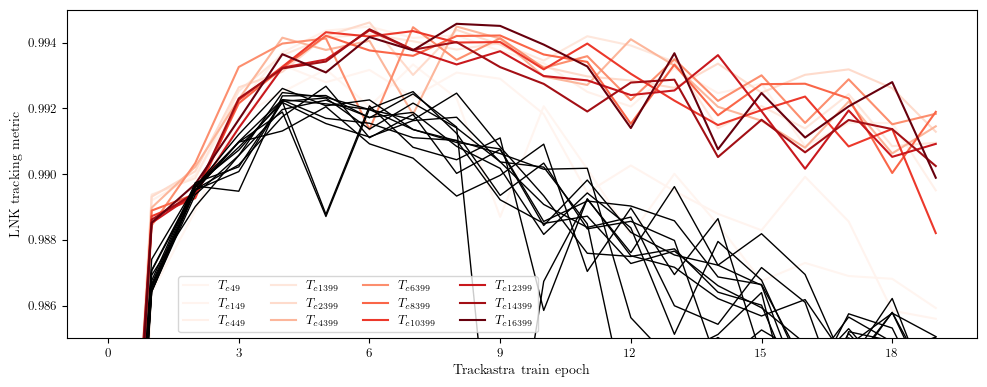

In [34]:
from matplotlib.ticker import MaxNLocator




import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(10, 4))

# Ensure numeric sorting of keys
sorted_keys = sorted(meanlists.keys(), key=int)

# Normalize key values for color mapping
key_values = [int(k) for k in sorted_keys]
norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.Reds

# Plot main curves with increasing red intensity
for k in sorted_keys:
    color = cmap(norm(int(k)))
    plt.plot(meanlists[k][:20], label=rf"$T_{{c{k}}}$", color=color)

# Plot baselines in black (no legend entries)
for ml in baseline_meanlists.values():
    plt.plot(ml[:20], color='black', linewidth=1)

plt.ylim(0.985, 0.995)
plt.legend(loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.32, 0))

plt.xlabel("Trackastra train epoch")
plt.ylabel("LNK tracking metric")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()

plt.savefig("monochromatic_compute_scaling.pdf")


In [35]:
# max of each main curve (first 20 points), including index
max_per_key = []
for k in sorted_keys:
    y = meanlists[k][:20]
    if not y:
        continue
    m = max(y)
    i = y.index(m)  # index within the first 20 points (0-based)
    max_per_key.append((k, m, i))

# sort by max value descending
max_per_key.sort(key=lambda x: x[1], reverse=True)

print("Maximum per line (descending), using first 20 points:")
for k, m, i in max_per_key:
    print(f"  key={k:>3}   label=T_c{k:<3}   max={m:.6f}   idx={i}")


Maximum per line (descending), using first 20 points:
  key=2399   label=T_c2399   max=0.994616   idx=6
  key=16399   label=T_c16399   max=0.994575   idx=8
  key=4399   label=T_c4399   max=0.994493   idx=8
  key=449   label=T_c449   max=0.994490   idx=6
  key=6399   label=T_c6399   max=0.994472   idx=7
  key=14399   label=T_c14399   max=0.994409   idx=6
  key=12399   label=T_c12399   max=0.994376   idx=6
  key=10399   label=T_c10399   max=0.994354   idx=7
  key=1399   label=T_c1399   max=0.994261   idx=6
  key=8399   label=T_c8399   max=0.994219   idx=9
  key= 49   label=T_c49    max=0.993338   idx=7
  key=149   label=T_c149   max=0.993321   idx=4


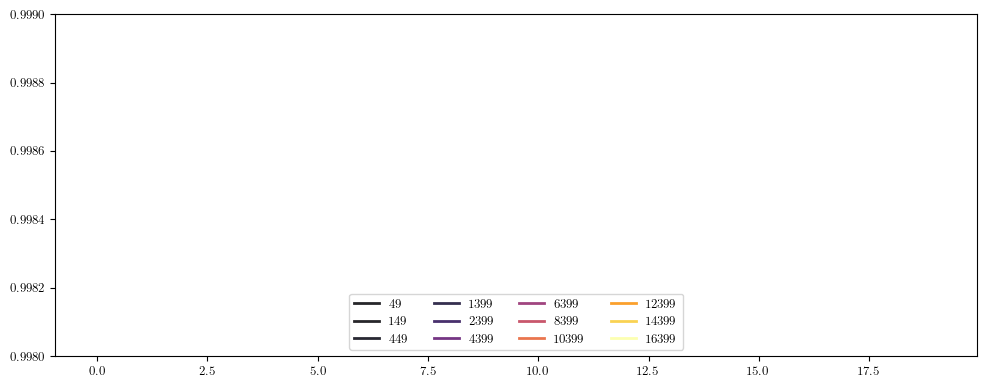

In [36]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(10, 4))

# Numerically sort keys
sorted_keys = sorted(meanlists.keys(), key=int)

# Normalize key values for colormap scaling
key_values = [int(k) for k in sorted_keys]
norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.inferno

for k in sorted_keys:
    color = cmap(norm(int(k)))
    plt.plot(
        meanlists[k][:20],
        label=str(k),
        color=color,
        linewidth=2.0,
        alpha=0.85
    )


# Plot baselines as faint reference curves
for ml in baseline_meanlists.values():
    plt.plot(
        ml[:20],
        linestyle="--",
        color="0.6",      # neutral gray
        linewidth=0.8,
        alpha=0.5,
        label="_nolegend_"
    )


plt.ylim(0.998, 0.999)
plt.legend(loc="lower center", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


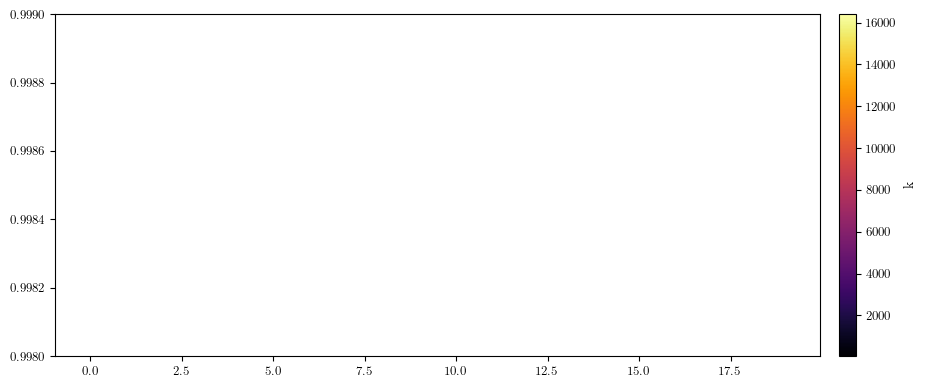

In [37]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 4))

sorted_keys = sorted(meanlists.keys(), key=int)
key_values = [int(k) for k in sorted_keys]

norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.inferno

# Colored series with white halo
for k in sorted_keys:
    color = cmap(norm(int(k)))
    (line,) = ax.plot(
        meanlists[k][:20],
        color=color,
        linewidth=2.2,
        alpha=0.95,
        zorder=int(k),
    )
    line.set_path_effects([
        pe.Stroke(linewidth=4.5, foreground="white"),
        pe.Normal()
    ])

# Baselines
for ml in baseline_meanlists.values():
    ax.plot(ml[:20], "--", color="blue", linewidth=1, alpha=0.6, zorder=0)

ax.set_ylim(0.998, 0.999)

# Colorbar keyed to k
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("k")

fig.tight_layout()
plt.show

plt.savefig("compute_scaling_fluo_draft.pdf")

In [38]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd

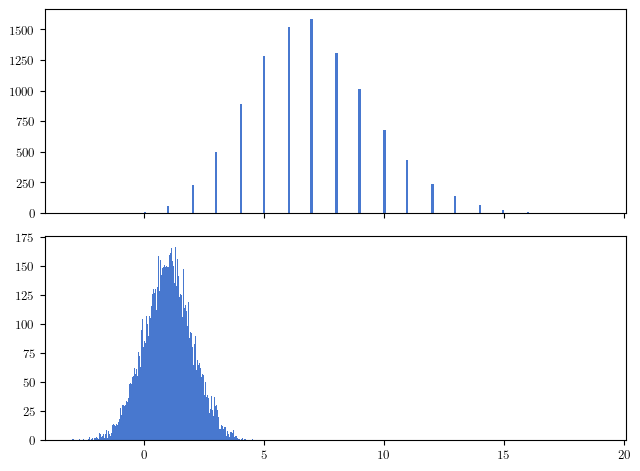

In [39]:
plt.style.use("seaborn-v0_8-muted")
def set_size(width_pt=472.31595, fraction=1, subplots=(1, 1)):
    """Set figure dimensions nicely

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5 ** .5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return fig_width_in, fig_height_in

# Colormap with University colors
colors = ["white", "#005f9b", "#153268"]
nodes = [0.0, 0.8, 1.0]
unimap = matplotlib.colors.LinearSegmentedColormap.from_list("unimap", list(zip(nodes, colors)))
unimap_r = unimap.reversed()
try:
    matplotlib.colormaps.register(cmap=unimap)
    matplotlib.colormaps.register(cmap=unimap_r)
except ValueError:
    pass

# LaTeX text renderer
plt.rcParams.update({
    "font.family": "serif",  # use serif/main font for text elements
    "font.serif": "Computer Modern Roman",
    "text.usetex": True,  # use inline math for ticks
    "text.latex.preamble": r"\usepackage{amsmath}",
    "pgf.rcfonts": False,  # don't setup fonts from rc parameters
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10.95,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    # Cmap
    "image.cmap": "unimap"
})
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=set_size(fraction=1, subplots=(1.2, 1)), sharex=True)

ax1.hist(np.random.poisson(7, 10000), bins=200)
ax2.hist(np.random.normal(1, 1, 10000), bins=200)

plt.tight_layout()
plt.show()
fig.savefig('style.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [40]:
cmap = mpl.cm.get_cmap('Set2')
num_colors = 12

colors = [cmap(i / num_colors) for i in range(num_colors)]
ca = colors[0]
cb = colors[2]

/tmp/ipykernel_12446/2254580673.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Set2')


In [41]:
import tol_colors as tc

In [44]:
treatment_compute_max_map

defaultdict(list,
            {8399: [0.9950068870523416,
              0.9950201313837678,
              0.9951658190294554,
              0.9956955922865014,
              0.9947155117609664,
              0.9941460055096418],
             6399: [0.9951525746980292,
              0.9939076075439712,
              0.9950201313837678,
              0.99504662004662,
              0.9956426149607968],
             49: [0.9938281415554144,
              0.9931261919898284,
              0.9940400508582328,
              0.9933381012926468,
              0.9939473405382496,
              0.993722186904005],
             449: [0.9959075015893196,
              0.9945698241152786,
              0.9955101716465352,
              0.9948082220809492,
              0.99504662004662,
              0.9947817334180972],
             4399: [0.994953909726637,
              0.99521879635516,
              0.9953247510065693,
              0.9954174613265524,
              0.9947552447552448,
       

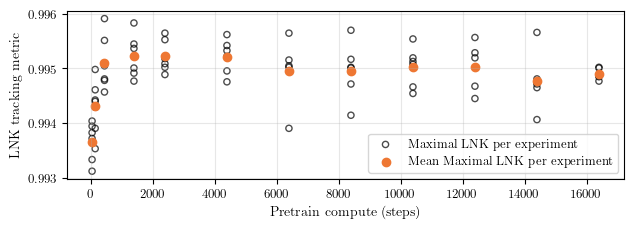

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# --- Flatten baseline_compute_max_map into x/y arrays ---
x = []
y = []
means = []

for k, l in treatment_compute_max_map.items():
    for v in l:
        x.append(k)
        y.append(v)
    means.append(sum(l) / len(l))

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)

"""
if x.size < 2:
    raise ValueError("Need at least 2 (k, v) points to fit a regression.")

# --- Linear regression: y = m*x + b ---
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

# --- R^2 ---
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

print(f"Slope (m):     {m:.6g}")
print(f"Intercept (b): {b:.6g}")
print(f"R²:            {r_squared:.6g}")
"""

# --- Plot points + regression line ---
fig, ax = plt.subplots(1, 1, figsize=set_size(fraction=1, subplots=(1.2, 2)))
ax.scatter(x, y, s=20, alpha=0.7, label="Maximal LNK per experiment", facecolors='none', edgecolors='black')

"""
# Smooth line across the x-rangec 
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b
ax.plot(x_line, y_line, c="red", linewidth=1, label=f"Fit: y = {m:.3g}x+{b:.3g} (R²={r_squared:.3f})")
"""
ax.scatter([k for k in treatment_compute_max_map.keys()], means, color=tc.vibrant[0], label="Mean Maximal LNK per experiment")

ax.set_xlabel("Pretrain compute (steps)")
ax.set_ylabel("LNK tracking metric")

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.savefig("a_pre_compute_scaling_fluo.pdf")

Michaelis–Menten fit: y = y0 + (A*x)/(K + x)
y0: 0.990546
A:  0.0045239
K:  22.6551
R²:  0.479744


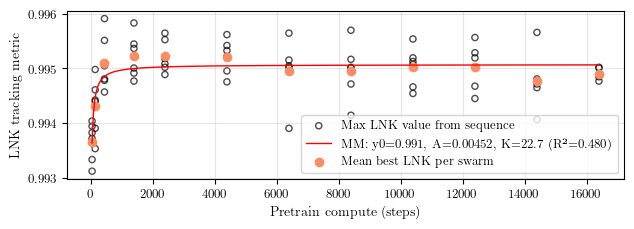

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Flatten treatment_compute_max_map into x/y arrays + group means ---
x = []
y = []
means = []

for k, l in treatment_compute_max_map.items():
    for v in l:
        x.append(k)
        y.append(v)
    means.append(sum(l) / len(l))

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)

if x.size < 3:
    raise ValueError("Need at least 3 points to fit Michaelis–Menten (y0, A, K).")

# --- Michaelis–Menten model: y = y0 + (A*x)/(K + x) ---
def michaelis_menten(x, y0, A, K):
    x = np.asarray(x, dtype=float)
    return y0 + (A * x) / (K + x)

# --- Initial guesses (robust defaults) ---
y0_init = float(np.min(y))
A_init  = float(np.max(y) - np.min(y))
K_init  = float(np.median(x[x > 0])) if np.any(x > 0) else 1.0
p0 = [y0_init, A_init, K_init]

# --- Constrain parameters to sensible ranges (optional but recommended) ---
# y0 in [0, 1], A in [-1, 1] (allow small negative if data decreases), K >= 0
bounds = ([0.0, -1.0, 0.0], [1.0, 1.0, np.inf])

# --- Fit ---
params, cov = curve_fit(
    michaelis_menten,
    x, y,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
y0_hat, A_hat, K_hat = params

# --- Predictions + R^2 ---
y_pred = michaelis_menten(x, y0_hat, A_hat, K_hat)

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

print("Michaelis–Menten fit: y = y0 + (A*x)/(K + x)")
print(f"y0: {y0_hat:.6g}")
print(f"A:  {A_hat:.6g}")
print(f"K:  {K_hat:.6g}")
print(f"R²:  {r_squared:.6g}")

# --- Plot points + fitted curve ---
fig, ax = plt.subplots(1, 1, figsize=set_size(fraction=1, subplots=(1.2, 2)))
ax.scatter(x, y, s=20, alpha=0.7, label="Max LNK value from sequence", facecolors="none", edgecolors="black")

# Smooth curve across x-range
x_line = np.linspace(x.min(), x.max(), 400)
y_line = michaelis_menten(x_line, y0_hat, A_hat, K_hat)
ax.plot(
    x_line, y_line, c="red", linewidth=1,
    label=f"MM: y0={y0_hat:.3g}, A={A_hat:.3g}, K={K_hat:.3g} (R²={r_squared:.3f})"
)

# Overlay group means (as in your original code)
ax.scatter([k for k in treatment_compute_max_map.keys()], means, color=colors[2], label="Mean best LNK per swarm")

ax.set_xlabel("Pretrain compute (steps)")
ax.set_ylabel("LNK tracking metric")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.savefig("jan_michaelis_menten.pdf")
